# 02 – Frequency GLM (Poisson)
Fit a Poisson GLM for claim frequency using the sample dataset.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
from glm_pricing.data import load_freq
from glm_pricing.preprocessing import cap_exposure, cap_claimnb, prepare_features, train_test_split_policy
from glm_pricing.models import fit_frequency
from glm_pricing.evaluation import poisson_deviance, lift_chart

df = load_freq("../data/sample/freMTPL_sample.csv")
df = cap_exposure(df)
df = cap_claimnb(df)
df = prepare_features(df)
print("Preprocessed shape:", df.shape)
print(df[["ClaimNb", "Exposure", "BonusMalusCapped", "LogDensity", "VehAgeBin", "DrivAgeBin"]].head())


Preprocessed shape: (5000, 17)
   ClaimNb  Exposure  BonusMalusCapped  LogDensity VehAgeBin DrivAgeBin
0        1      0.84                50    5.840642     young      41-50
1        1      0.84                50    4.934474     young      41-50
2        1      0.90                50    4.442651       new      41-50
3        1      0.72                50    4.927254       new        71+
4        1      0.70                50    5.209486       new      41-50


In [3]:
train, test = train_test_split_policy(df)
print(f"Train: {len(train)} rows | Test: {len(test)} rows")
print(f"Train claim rate: {(train['ClaimNb'].astype(float)>0).mean():.3f}")
print(f"Test  claim rate: {(test['ClaimNb'].astype(float)>0).mean():.3f}")


Train: 4000 rows | Test: 1000 rows
Train claim rate: 0.051
Test  claim rate: 0.047


In [4]:
FREQ_FEATURES = ["BonusMalusCapped", "LogDensity", "VehPower", "VehAgeBin", "DrivAgeBin", "VehGas", "Area"]
freq_model = fit_frequency(train, FREQ_FEATURES)
print(freq_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:                 4000
Model:                            GLM   Df Residuals:                     3982
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -819.53
Date:                Sat, 23 May 2026   Deviance:                       1224.9
Time:                        02:00:46   Pearson chi2:                 8.12e+03
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02250
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -1.5036    

In [5]:
# Evaluate on test set
import numpy as np
freq_pred = freq_model.predict(test, offset=np.log(test["Exposure"].clip(lower=1e-6)))
pois_dev = poisson_deviance(test["ClaimNb"].values.astype(float), freq_pred.values, exposure=test["Exposure"].values)
print(f"Poisson Deviance (test): {pois_dev:.6f}")
print(f"Mean predicted claims: {freq_pred.mean():.4f}")
print(f"Mean actual claims:    {test['ClaimNb'].astype(float).mean():.4f}")


Poisson Deviance (test): 0.364324
Mean predicted claims: 0.0527
Mean actual claims:    0.0500


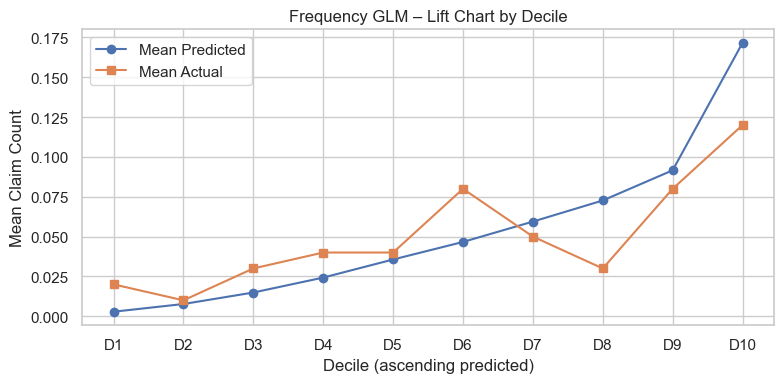

Frequency GLM complete.


In [6]:
# Lift chart
lc = lift_chart(test["ClaimNb"].astype(float).values, freq_pred.values, n_bins=10)
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(lc))
ax.plot(x, lc["mean_pred"], marker="o", label="Mean Predicted")
ax.plot(x, lc["mean_actual"], marker="s", label="Mean Actual")
ax.set_xticks(x)
ax.set_xticklabels([f"D{i+1}" for i in x])
ax.set_title("Frequency GLM – Lift Chart by Decile")
ax.set_xlabel("Decile (ascending predicted)")
ax.set_ylabel("Mean Claim Count")
ax.legend()
plt.tight_layout()
plt.savefig("../data/sample/freq_lift_chart.png", dpi=80)
plt.show()
print("Frequency GLM complete.")
